In [1]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import seaborn as sns
import matplotlib.pyplot as plt
import re
import scipy.sparse as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score

In [2]:
df = pd.read_csv(r'C:\Users\LOQ\Desktop\Machine Learning\Decision Tree\data\raw\apple_iphone_11_reviews.csv')
df.head()

,index,product,helpful_count,total_comments,url,review_country,reviewed_at,review_text,review_rating,product_company,profile_name,review_title
0,0,Apple iPhone XR (64GB) - Black,"5,087 people found this helpful",24,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2018-12-12,NOTE:,3.0 out of 5 stars,Apple,Sameer Patil,"Which iPhone you should Purchase ? iPhone 8, X..."
1,1,Apple iPhone XR (64GB) - Black,"2,822 people found this helpful",6,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2018-11-17,Very bad experience with this iPhone xr phone....,1.0 out of 5 stars,Apple,Amazon Customer,Don't buy iPhone xr from Amazon.
2,2,Apple iPhone XR (64GB) - Black,"1,798 people found this helpful",0,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2019-01-27,Amazing phone with amazing camera coming from ...,5.0 out of 5 stars,Apple,A,Happy with the purchase
3,3,Apple iPhone XR (64GB) - Black,"1,366 people found this helpful",14,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2019-05-02,So I got the iPhone XR just today. The product...,1.0 out of 5 stars,Apple,Shubham Dutta,Amazon is not an apple authorised reseller. Pl...
4,4,Apple iPhone XR (64GB) - Black,536 people found this helpful,5,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2019-05-24,I've been an android user all my life until I ...,5.0 out of 5 stars,Apple,Nepuni Lokho,Excellent Battery life and buttery smooth UI


In [3]:
raw_data = df.copy()

In [4]:
raw_data.sample(5)

,index,product,helpful_count,total_comments,url,review_country,reviewed_at,review_text,review_rating,product_company,profile_name,review_title
4611,4611,Apple iPhone XR (64GB) - Black,0,0,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2019-10-03,Very good and smooth,5.0 out of 5 stars,Apple,Beer,Wow.....
3286,3286,Apple iPhone XR (64GB) - Black,0,0,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2019-12-08,Awesome!,5.0 out of 5 stars,Apple,Anand,Awesome
3552,3552,Apple iPhone XR (64GB) - Black,0,0,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2019-11-07,Very good phone,5.0 out of 5 stars,Apple,AMIT KASHYAP,Best iPhone in terms of battery
132,132,Apple iPhone XR (64GB) - Black,0,0,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2019-11-21,"Easy to use, serves the purpose. I was an andr...",4.0 out of 5 stars,Apple,aj_adtech,Peace of mind
1526,1526,Apple iPhone XR (64GB) - Black,One person found this helpful,0,https://www.amazon.in/Apple-iPhone-XR-64GB-Bla...,India,2020-03-09,"The product, delivery everything on point.",5.0 out of 5 stars,Apple,Amazon Customer,Perfect.


In [5]:
raw_data.shape

(5010, 12)

In [6]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   index            5010 non-null   int64
 1   product          5010 non-null   str  
 2   helpful_count    5010 non-null   str  
 3   total_comments   5010 non-null   int64
 4   url              5010 non-null   str  
 5   review_country   5010 non-null   str  
 6   reviewed_at      5010 non-null   str  
 7   review_text      5007 non-null   str  
 8   review_rating    5010 non-null   str  
 9   product_company  5010 non-null   str  
 10  profile_name     5010 non-null   str  
 11  review_title     5008 non-null   str  
dtypes: int64(2), str(10)
memory usage: 1.9 MB


In [7]:
raw_data.describe()

,index,total_comments
count,5010.000000,5010.000000
mean,2504.500000,0.030938
std,1446.406755,0.589420
min,0.000000,0.000000
25%,1252.250000,0.000000
50%,2504.500000,0.000000
75%,3756.750000,0.000000
max,5009.000000,24.000000


In [8]:
raw_data.isnull().sum()

index              0
product            0
helpful_count      0
total_comments     0
url                0
review_country     0
reviewed_at        0
review_text        3
review_rating      0
product_company    0
profile_name       0
review_title       2
dtype: int64

In [9]:
raw_data = raw_data.dropna()

In [10]:
raw_data = raw_data.drop_duplicates(subset=['review_text'])   # FIX: stop leakage

In [11]:
raw_data['product'].value_counts()

product
Apple iPhone XR (64GB) - Black    4088
Name: count, dtype: int64

In [12]:
raw_data['helpful_count'].value_counts()

helpful_count
0                                  3391
One person found this helpful       483
2 people found this helpful         101
3 people found this helpful          26
4 people found this helpful          12
5 people found this helpful          11
9 people found this helpful           5
15 people found this helpful          4
6 people found this helpful           4
7 people found this helpful           4
14 people found this helpful          3
10 people found this helpful          3
35 people found this helpful          2
19 people found this helpful          2
12 people found this helpful          2
8 people found this helpful           2
5,087 people found this helpful       1
2,822 people found this helpful       1
1,798 people found this helpful       1
1,366 people found this helpful       1
536 people found this helpful         1
313 people found this helpful         1
189 people found this helpful         1
164 people found this helpful         1
124 people found this help

In [13]:
raw_data['total_comments'].value_counts()

total_comments
0     4041
1       38
2        4
24       1
6        1
14       1
5        1
3        1
Name: count, dtype: int64

In [14]:
raw_data['review_country'].value_counts()

review_country
India     4088
Name: count, dtype: int64

In [15]:
raw_data['reviewed_date'] = pd.to_datetime(raw_data['reviewed_at'])
raw_data['reviewed_date']

0      2018-12-12
1      2018-11-17
2      2019-01-27
3      2019-05-02
4      2019-05-24
          ...    
4998   2019-06-16
5000   2019-10-25
5005   2019-11-13
5006   2019-11-15
5008   2019-11-10
Name: reviewed_date, Length: 4088, dtype: datetime64[us]

In [16]:
raw_data['reviewed_year'] = raw_data['reviewed_date'].dt.year

<Axes: >

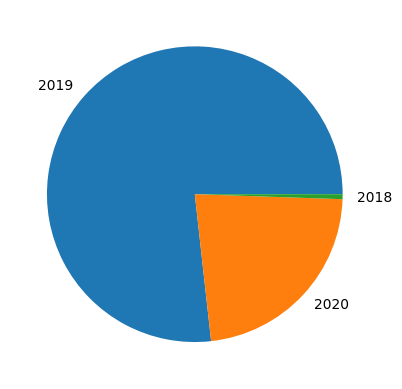

In [17]:
raw_data['reviewed_year'].value_counts().plot(kind='pie')

In [18]:
raw_data['reviewed_month'] = raw_data['reviewed_date'].dt.month

<Axes: xlabel='reviewed_month'>

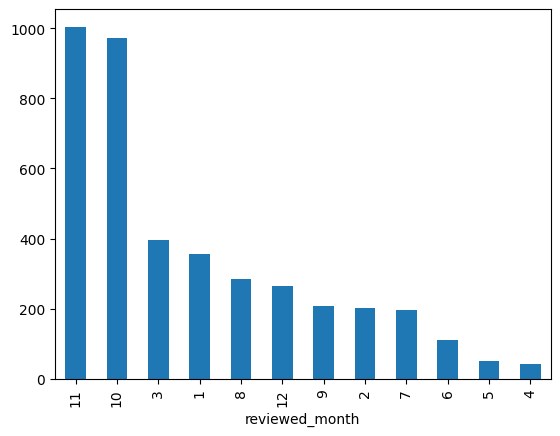

In [19]:
raw_data['reviewed_month'].value_counts().plot(kind='bar')

In [20]:
raw_data['rating'] = raw_data['review_rating'].str.extract(r'(\d+\.\d+|\d+)').astype(float)

<Axes: xlabel='rating'>

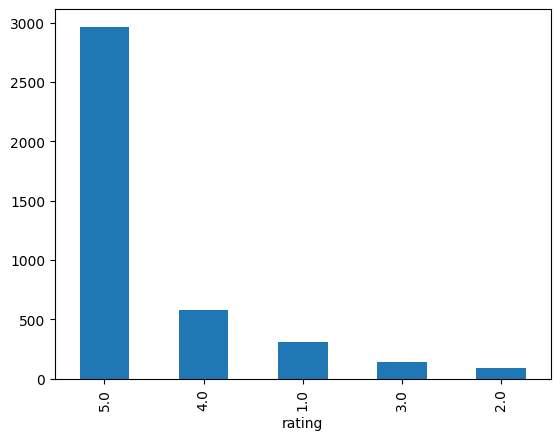

In [21]:
raw_data['rating'].value_counts().plot(kind='bar')

In [22]:
def sentiment_label(value):
    if value <= 2:
        return "negative"
    elif value == 3:
        return "neutral"
    else:
        return 'positive'


raw_data['sentiment'] = raw_data['rating'].apply(sentiment_label)

In [23]:
raw_data = raw_data[raw_data['rating'] != 3].copy()   # FIX: neutral can't be predicted

In [24]:
raw_data['sentiment'].value_counts()

sentiment
positive    3549
negative     395
Name: count, dtype: int64

<Axes: xlabel='sentiment'>

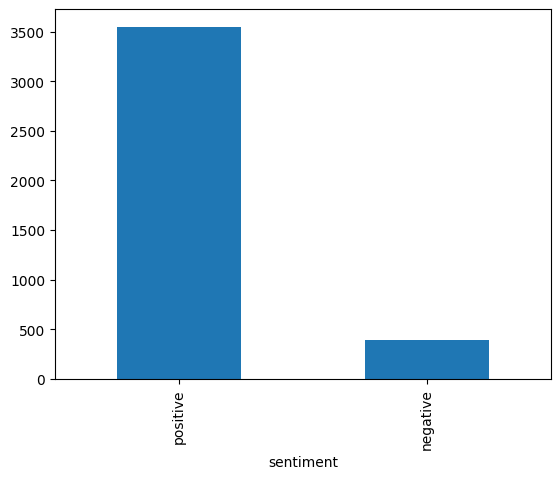

In [25]:
raw_data['sentiment'].value_counts().plot(kind='bar')

In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # 3. Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z]", " ", text)
    
    # 4. Tokenize (split words)
    words = text.split()
    
    # 5. Remove stopwords + stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # 6. Join back to sentence
    return " ".join(words)

In [28]:
raw_data['clean_text'] = raw_data['review_text'].apply(clean_text)

In [29]:
raw_data['clean_title'] = raw_data['review_title'].apply(clean_text)

In [30]:
raw_data['clean_text']

1       bad experi iphon xr phone back camera found de...
2       amaz phone amaz camera come iphon plu great se...
3       got iphon xr today product look amaz unfortun ...
4       android user life decid tri iphon xr io love c...
5       deliv phone work immedi remov box abl return n...
                              ...                        
4998                                   call qualiti worst
5000                                                super
5005                                              dhamaka
5006                                               goodby
5008                                              superbb
Name: clean_text, Length: 3944, dtype: str

In [31]:
# Duplicates -- repeated review text leaks between train/test if not removed
print("Exact duplicate rows :", raw_data.duplicated().sum())
print("Duplicate review_text:", raw_data['review_text'].duplicated().sum())

# Length -- catch near-empty junk reviews
raw_data['char_len']   = raw_data['review_text'].astype(str).str.len()
raw_data['word_count'] = raw_data['review_text'].astype(str).str.split().str.len()
print("\nChar-length summary:")
print(raw_data['char_len'].describe().round(1))
print("Reviews with < 3 words:", (raw_data['word_count'] < 3).sum())


Exact duplicate rows : 0
Duplicate review_text: 0

Char-length summary:
count    3944.0
mean       77.2
std        99.3
min         1.0
25%        21.0
50%        41.0
75%        93.0
max      1001.0
Name: char_len, dtype: float64
Reviews with < 3 words: 562


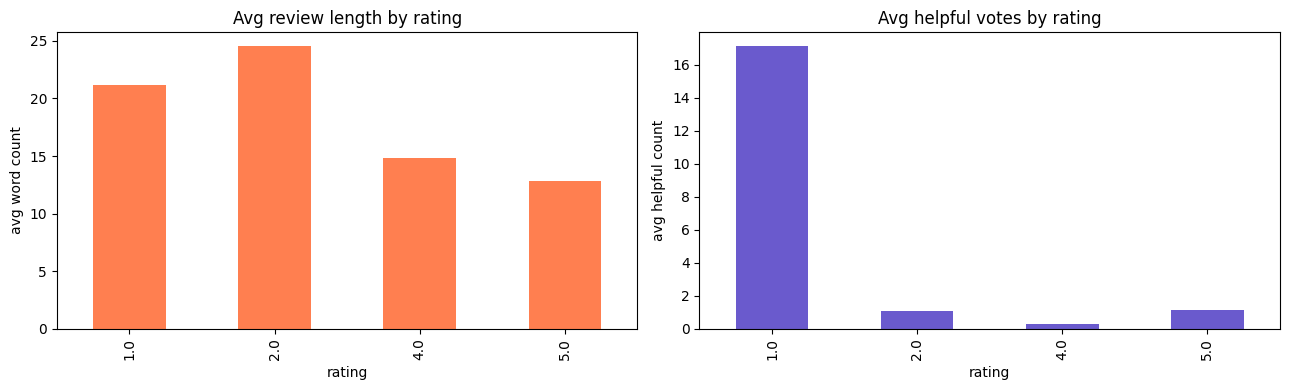

Length and helpful-votes both vary with rating -> both are useful features.


In [32]:
def parse_help(s):
    m = re.search(r'([\d,]+)', str(s))
    return int(m.group(1).replace(',', '')) if m else 0
raw_data['helpful_num'] = raw_data['helpful_count'].apply(parse_help)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
raw_data.groupby('rating')['word_count'].mean().plot(
    kind='bar', ax=ax[0], color='coral', title='Avg review length by rating')
ax[0].set_ylabel('avg word count')
raw_data.groupby('rating')['helpful_num'].mean().plot(
    kind='bar', ax=ax[1], color='slateblue', title='Avg helpful votes by rating')
ax[1].set_ylabel('avg helpful count')
plt.tight_layout(); plt.show()

print("Length and helpful-votes both vary with rating -> both are useful features.")

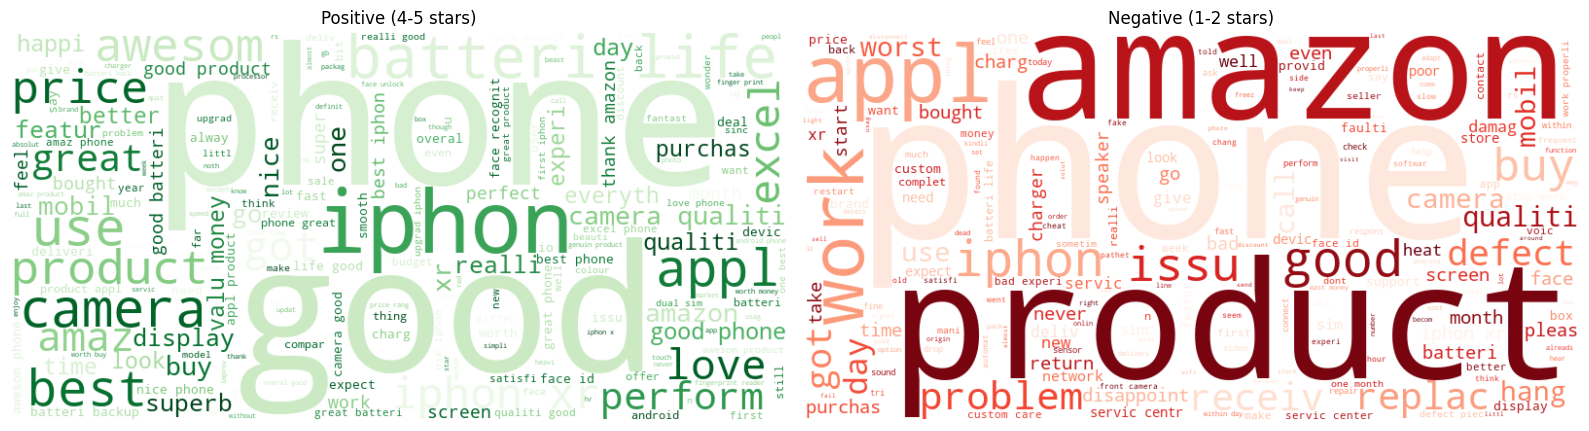

In [33]:
from wordcloud import WordCloud, STOPWORDS

def cloud_text(df_subset):
    txt = " ".join(df_subset['clean_text'].dropna().astype(str)).lower()
    txt = re.sub(r'[^\w\s]', '', txt)
    return " ".join(w for w in txt.split() if w not in STOPWORDS)

pos = cloud_text(raw_data[raw_data['rating'] >= 4])
neg = cloud_text(raw_data[raw_data['rating'] <= 2])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for a, text, title, cmap in [(ax[0], pos, 'Positive (4-5 stars)', 'Greens'),
                              (ax[1], neg, 'Negative (1-2 stars)', 'Reds')]:
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap).generate(text)
    a.imshow(wc, interpolation='bilinear'); a.axis('off'); a.set_title(title)
plt.tight_layout(); plt.show()

In [34]:
raw_data["text"] = (raw_data["clean_title"].fillna("") + " " +
              raw_data["clean_text"].fillna(""))

In [35]:
train, test = train_test_split(raw_data, test_size=0.2, random_state=42,
                               stratify=raw_data['sentiment'])

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3)
Xtr_text = vectorizer.fit_transform(train['text'])
Xte_text = vectorizer.transform(test['text'])

In [36]:
num = ['helpful_num', 'word_count']
X_train = sp.hstack([Xtr_text, train[num].values])
X_test  = sp.hstack([Xte_text, test[num].values])
y_train, y_test = train['sentiment'], test['sentiment']

In [37]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print("Dummy baseline macro-F1:", round(f1_score(y_test, dummy.predict(X_test), average='macro'), 3))


Dummy baseline macro-F1: 0.474


In [38]:
dt_model = DecisionTreeClassifier(max_depth=12, min_samples_leaf=5,
                                  class_weight='balanced', random_state=42)

In [39]:
print("CV macro-F1:", round(cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1_macro').mean(), 3))

dt_model.fit(X_train, y_train)
print(classification_report(y_test, dt_model.predict(X_test), zero_division=0))

CV macro-F1: 0.68
              precision    recall  f1-score   support

    negative       0.28      0.80      0.41        79
    positive       0.97      0.77      0.86       710

    accuracy                           0.77       789
   macro avg       0.62      0.78      0.63       789
weighted avg       0.90      0.77      0.81       789



In [40]:
def predict_review(review, helpful_votes=0):
    """Predict sentiment of any new review using the trained model."""
    text = clean_text(review)                       # same cleaning as training
    word_count = len(str(review).split())           # same numeric feature
    tfidf = vectorizer.transform([text])            # use the FITTED vectorizer (don't refit!)
    X = sp.hstack([tfidf, [[helpful_votes, word_count]]])
    label = dt_model.predict(X)[0]
    confidence = round(max(dt_model.predict_proba(X)[0]), 2)
    return label, confidence

In [41]:
reviews = [
    "This phone is amazing, best purchase ever, camera is fantastic!",
    "Terrible product. Battery died in a week and screen cracked.",
    "worst phone, totally disappointed, do not buy",
]
for r in reviews:
    label, conf = predict_review(r)
    print(f"[{label} | {conf}]  {r}")

[positive | 1.0]  This phone is amazing, best purchase ever, camera is fantastic!
[negative | 0.87]  Terrible product. Battery died in a week and screen cracked.
[negative | 0.87]  worst phone, totally disappointed, do not buy


In [42]:
import joblib
joblib.dump({"vectorizer": vectorizer, "model": dt_model}, "sentiment_model.joblib")
print("saved!")

saved!
